# C题第一问：单日购电与储能调度

**编程手工作本**　｜　144个时段　｜　线性规划与物理约束验证

本文件已经保存实际执行的表格和图像。输入数据也内置在文件中，因此单独下载此Notebook即可重跑。

**怎么用：**在VS Code打开本文件，右上角选择`cumcm2026`对应的Python内核，然后按`Shift+Enter`逐格执行，或者点击`Run All`。修改参数后，从参数单元格开始重新运行后续所有单元格。

如果缺少库，在激活环境的终端中运行：
```powershell
python -m pip install numpy pandas scipy matplotlib ipykernel
```

**本次假设：**暂按采样值代表此前10分钟区间的平均功率；充电和放电效率各90%；日初日末6000kWh；允许弃光，不售电。原模板时间标签歧义仍未解决，下面的结果按明确的物理区间保存，尚不直接填写官方`result1.xlsx`。

默认数据与参数下，购电费应约为 **35,126.9486元**。不同求解器可能给出等价的最优安排，费用和约束比逐格决策是否一致更重要。


## 1. 导入库
本题使用CPU求解，不依赖Torch或GPU。


In [1]:
from pathlib import Path
from io import StringIO, BytesIO
import base64
import hashlib
import json
import platform
from time import perf_counter

import numpy as np
import pandas as pd
import scipy
from scipy.optimize import linprog, milp, Bounds, LinearConstraint
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ModuleNotFoundError:
    # 普通Python检查环境可预先提供display；Jupyter中会使用真正的富文本显示。
    if 'display' not in globals():
        display = print

pd.set_option('display.precision', 4)
plt.rcParams.update({'font.family':'DejaVu Sans', 'font.size':10,
                     'axes.spines.top':False, 'axes.spines.right':False})
print('Python:', platform.python_version(), '| SciPy:', scipy.__version__)


Python: 3.11.16 | SciPy: 1.17.1


## 2. 输入数据
下一格是折叠的内置CSV，仅用于保证Notebook可独立运行。首次使用无需编辑它。数值来自已完成预处理的`q1_typical_day.csv`。


In [2]:
EMBEDDED_INPUT_CSV = 'slot,source_time_label,sample_offset_minutes,interval_start_minute,interval_end_minute,price_yuan_per_kwh,load_kw,pv_forecast_kw,source_excel_row,load_kwh_approx,pv_forecast_kwh_approx,net_load_kw\n1,00:10:00,10,0,10,0.4248,3439.8466,0.0,2,573.3077666666667,0.0,3439.8466\n2,00:20:00,20,10,20,0.4245,3437.9792,0.0,3,572.9965333333333,0.0,3437.9792\n3,00:30:00,30,20,30,0.4269,3444.3031,0.0,4,574.0505166666667,0.0,3444.3031\n4,00:40:00,40,30,40,0.4272,3454.4437,0.0,5,575.7406166666666,0.0,3454.4437\n5,00:50:00,50,40,50,0.4271,3458.8273,0.0,6,576.4712166666667,0.0,3458.8273\n6,01:00:00,60,50,60,0.4285,3459.8401,0.0,7,576.6400166666666,0.0,3459.8401\n7,01:10:00,70,60,70,0.4311,3467.1582,0.0,8,577.8597,0.0,3467.1582\n8,01:20:00,80,70,80,0.4302,3467.9632,0.0,9,577.9938666666667,0.0,3467.9632\n9,01:30:00,90,80,90,0.4279,3466.9683,0.0,10,577.82805,0.0,3466.9683\n10,01:40:00,100,90,100,0.4312,3482.4927,0.0,11,580.41545,0.0,3482.4927\n11,01:50:00,110,100,110,0.4333,3495.0841,0.0,12,582.5140166666666,0.0,3495.0841\n12,02:00:00,120,110,120,0.4311,3498.4443,0.0,13,583.07405,0.0,3498.4443\n13,02:10:00,130,120,130,0.4293,3505.2295,0.0,14,584.2049166666667,0.0,3505.2295\n14,02:20:00,140,130,140,0.4324,3512.6387,0.0,15,585.4397833333334,0.0,3512.6387\n15,02:30:00,150,140,150,0.4367,3516.8685,0.0,16,586.14475,0.0,3516.8685\n16,02:40:00,160,150,160,0.4348,3517.9246,0.0,17,586.3207666666666,0.0,3517.9246\n17,02:50:00,170,160,170,0.4335,3518.5518,0.0,18,586.4253,0.0,3518.5518\n18,03:00:00,180,170,180,0.4357,3521.0976,0.0,19,586.8496,0.0,3521.0976\n19,03:10:00,190,180,190,0.4374,3526.9261,0.0,20,587.8210166666667,0.0,3526.9261\n20,03:20:00,200,190,200,0.4371,3537.2854,0.0,21,589.5475666666667,0.0,3537.2854\n21,03:30:00,210,200,210,0.4356,3544.8808,0.0,22,590.8134666666666,0.0,3544.8808\n22,03:40:00,220,210,220,0.4353,3541.2787,0.0,23,590.2131166666667,0.0,3541.2787\n23,03:50:00,230,220,230,0.436,3546.3976,0.0,24,591.0662666666666,0.0,3546.3976\n24,04:00:00,240,230,240,0.4378,3560.207,0.0,25,593.3678333333334,0.0,3560.207\n25,04:10:00,250,240,250,0.4401,3561.9581,0.0,26,593.6596833333333,0.0,3561.9581\n26,04:20:00,260,250,260,0.4389,3556.7183,0.0,27,592.7863833333333,0.0,3556.7183\n27,04:30:00,270,260,270,0.4364,3560.0272,0.0,28,593.3378666666666,0.0,3560.0272\n28,04:40:00,280,270,280,0.4393,3580.654,0.5994,29,596.7756666666667,0.0999,3580.0546\n29,04:50:00,290,280,290,0.4422,3586.916,0.2345,30,597.8193333333334,0.03908333333333333,3586.6815\n30,05:00:00,300,290,300,0.4395,3571.2635,0.2885,31,595.2105833333334,0.04808333333333333,3570.975\n31,05:10:00,310,300,310,0.4333,3562.3171,18.6781,32,593.7195166666667,3.1130166666666668,3543.639\n32,05:20:00,320,310,320,0.4439,3591.3809,54.4698,33,598.5634833333334,9.0783,3536.9111000000003\n33,05:30:00,330,320,330,0.4301,3579.7045,108.9718,34,596.6174166666666,18.161966666666668,3470.7327\n34,05:40:00,340,330,340,0.3713,3486.119,184.1603,35,581.0198333333334,30.693383333333333,3301.9587\n35,05:50:00,350,340,350,0.5708,3823.8994,277.0582,36,637.3165666666666,46.17636666666667,3546.8412\n36,06:00:00,360,350,360,0.9099,4398.0727,388.5494,37,733.0121166666667,64.75823333333334,4009.5233\n37,06:10:00,370,360,370,0.9368,4454.0123,521.2803,38,742.3353833333334,86.88005,3932.7320000000004\n38,06:20:00,380,370,380,0.8758,4371.7919,672.7677,39,728.6319833333333,112.12795,3699.0242000000003\n39,06:30:00,390,380,390,0.8759,4392.953,844.2261,40,732.1588333333334,140.70435,3548.7269000000006\n40,06:40:00,400,390,400,0.8601,4384.5956,1039.6744,41,730.7659333333332,173.2790666666667,3344.9211999999998\n41,06:50:00,410,400,410,0.8442,4434.7757,1259.3375,42,739.1292833333333,209.88958333333335,3175.4382\n42,07:00:00,420,410,420,0.8334,4523.4561,1508.6318,43,753.90935,251.43863333333334,3014.8243\n43,07:10:00,430,420,430,0.8092,4524.0721,1791.4107,44,754.0120166666667,298.56845,2732.6614000000004\n44,07:20:00,440,430,440,0.7972,4545.8867,2085.4865,45,757.6477833333333,347.5810833333333,2460.4002\n45,07:30:00,450,440,450,0.7644,4523.2418,2381.2611,46,753.8736333333333,396.87685000000005,2141.9806999999996\n46,07:40:00,460,450,460,0.6899,4383.3566,2683.1752,47,730.5594333333333,447.1958666666667,1700.1814\n47,07:50:00,470,460,470,0.86,4910.4599,2986.3552,48,818.4099833333333,497.72586666666666,1924.1046999999999\n48,08:00:00,480,470,480,1.1617,5799.7327,3289.204,49,966.6221166666666,548.2006666666667,2510.5286999999994\n49,08:10:00,490,480,490,1.1683,5884.826,3593.3613,50,980.8043333333334,598.89355,2291.4647\n50,08:20:00,500,490,500,1.0956,5748.0713,3890.7332,51,958.0118833333332,648.4555333333334,1857.3380999999995\n51,08:30:00,510,500,510,1.0849,5769.0581,4181.3417,52,961.5096833333333,696.8902833333333,1587.7164000000002\n52,08:40:00,520,510,520,1.061,5754.2105,4471.7657,53,959.0350833333333,745.2942833333333,1282.4448000000002\n53,08:50:00,530,520,530,1.043,5824.1807,4752.8272,54,970.6967833333333,792.1378666666666,1071.3535000000002\n54,09:00:00,540,530,540,1.036,5954.2601,5021.9074,55,992.3766833333334,836.9845666666666,932.3527000000004\n55,09:10:00,550,540,550,1.0147,5958.9696,5285.4126,56,993.1616,880.9020999999999,673.5570000000007\n56,09:20:00,560,550,560,0.9922,5929.5554,5543.1742,57,988.2592333333333,923.8623666666667,386.3811999999998\n57,09:30:00,570,560,570,0.97,5923.7828,5788.4093,58,987.2971333333334,964.7348833333334,135.3734999999997\n58,09:40:00,580,570,580,0.9422,5907.586,6012.1304,59,984.5976666666667,1002.0217333333334,-104.54439999999977\n59,09:50:00,590,580,590,0.9569,5899.1262,6216.1528,60,983.1877,1036.0254666666667,-317.02660000000014\n60,10:00:00,600,590,600,0.9977,5902.2196,6409.5941,61,983.7032666666668,1068.2656833333333,-507.3744999999999\n61,10:10,610,600,610,0.9919,5897.4793,6599.3808,62,982.9132166666667,1099.8968,-701.9014999999999\n62,10:20,620,610,620,0.9588,5886.7568,6766.7204,63,981.1261333333333,1127.7867333333334,-879.9636\n63,10:30,630,620,630,0.9549,5873.4708,6914.5923,64,978.9118,1152.4320500000001,-1041.1215000000002\n64,10:40,640,630,640,0.9839,5858.0308,7064.2053,65,976.3384666666667,1177.36755,-1206.1744999999992\n65,10:50,650,640,650,0.799,5844.9948,7197.4315,66,974.1658000000001,1199.5719166666665,-1352.4366999999993\n66,11:00,660,650,660,0.5025,5839.0587,7303.1142,67,973.1764499999999,1217.1857,-1464.0555000000004\n67,11:10,670,660,670,0.4662,5838.7103,7387.6848,68,973.1183833333333,1231.2808,-1548.9745000000003\n68,11:20,680,670,680,0.5007,5823.4378,7459.227,69,970.5729666666666,1243.2045,-1635.7892000000002\n69,11:30,690,680,690,0.4827,5814.7932,7520.7191,70,969.1322,1253.4531833333333,-1705.9259000000002\n70,11:40,700,690,700,0.4785,5832.3951,7568.2039,71,972.06585,1261.3673166666667,-1735.8088000000007\n71,11:50,710,700,710,0.4662,5712.901,7592.1539,72,952.1501666666667,1265.3589833333333,-1879.2529000000004\n72,12:00,720,710,720,0.4432,5519.4607,7601.0433,73,919.9101166666666,1266.8405500000001,-2081.5826000000006\n73,12:10,730,720,730,0.4411,5494.7907,7612.316,74,915.7984499999999,1268.7193333333332,-2117.5253000000002\n74,12:20,740,730,740,0.4551,5514.4524,7602.6524,75,919.0754000000001,1267.1087333333332,-2088.2\n75,12:30,750,740,750,0.4463,5485.829,7554.1872,76,914.3048333333332,1259.0312000000001,-2068.3582000000006\n76,12:40,760,750,760,0.4113,5462.3628,7472.7384,77,910.3937999999999,1245.4564,-2010.3756000000003\n77,12:50,770,760,770,0.5682,5566.1066,7393.4172,78,927.6844333333333,1232.2362,-1827.3105999999998\n78,13:00,780,770,780,0.8279,5725.7548,7312.7979,79,954.2924666666667,1218.79965,-1587.0430999999999\n79,13:10,790,780,790,0.8636,5739.4957,7194.541,80,956.5826166666667,1199.0901666666666,-1455.0452999999998\n80,13:20,800,790,800,0.8416,5714.6836,7053.1371,81,952.4472666666667,1175.52285,-1338.4534999999996\n81,13:30,810,800,810,0.8618,5717.8505,6910.4064,82,952.9750833333333,1151.7344,-1192.5559000000003\n82,13:40,820,810,820,0.8623,5708.2486,6772.4075,83,951.3747666666667,1128.7345833333334,-1064.1589000000004\n83,13:50,830,820,830,0.9026,5696.9182,6607.36,84,949.4863666666666,1101.2266666666667,-910.4417999999996\n84,14:00,840,830,840,0.9754,5692.2983,6412.5085,85,948.7163833333334,1068.7514166666667,-720.2101999999995\n85,14:10,850,840,850,1.0002,5687.1291,6214.0158,86,947.85485,1035.6693,-526.8867\n86,14:20,860,850,860,0.9978,5678.962,6000.7112,87,946.4936666666667,1000.1185333333333,-321.7491999999993\n87,14:30,870,860,870,1.0271,5669.4508,5766.9816,88,944.9084666666666,961.1636,-97.53080000000045\n88,14:40,880,870,880,1.0906,5664.1948,5521.5066,89,944.0324666666667,920.2511,142.6882000000005\n89,14:50,890,880,890,0.9376,5672.7011,5268.781,90,945.4501833333334,878.1301666666667,403.9201000000003\n90,15:00,900,890,900,0.6694,5682.2544,5009.7152,91,947.0423999999999,834.9525333333332,672.5392000000002\n91,15:10,910,900,910,0.66,5669.0195,4743.4484,92,944.8365833333334,790.5747333333334,925.5711000000001\n92,15:20,920,910,920,0.7217,5656.3651,4471.224,93,942.7275166666667,745.2040000000001,1185.1410999999998\n93,15:30,930,920,930,0.7308,5657.0867,4188.2025,94,942.8477833333333,698.03375,1468.8841999999995\n94,15:40,940,930,940,0.7534,5662.6008,3889.3931,95,943.7668,648.2321833333333,1773.2077000000004\n95,15:50,950,940,950,0.7823,5669.2596,3594.5946,96,944.8766,599.0991,2074.6650000000004\n96,16:00,960,950,960,0.8055,5673.4767,3303.8878,97,945.5794500000001,550.6479666666667,2369.5889\n97,16:10,970,960,970,0.8271,5671.0146,2998.4247,98,945.1691000000001,499.73745,2672.5899000000004\n98,16:20,980,970,980,0.8519,5661.5926,2687.4131,99,943.5987666666666,447.90218333333337,2974.1794999999997\n99,16:30,990,980,990,0.8791,5665.8922,2383.1779,100,944.3153666666667,397.1963166666667,3282.7143\n100,16:40,1000,990,1000,0.9024,5689.0372,2089.1246,101,948.1728666666667,348.18743333333333,3599.9125999999997\n101,16:50,1010,1000,1010,0.9163,5603.6614,1791.0829,102,933.9435666666667,298.5138166666667,3812.5784999999996\n102,17:00,1020,1010,1020,0.9264,5466.7124,1501.7283,103,911.1187333333334,250.28805,3964.9841000000006\n103,17:10,1030,1020,1030,0.9462,5467.3939,1255.1723,104,911.2323166666666,209.19538333333333,4212.2216\n104,17:20,1040,1030,1040,0.9742,5464.727,1036.3323,105,910.7878333333333,172.72205,4428.3947\n105,17:30,1050,1040,1050,0.9862,5492.4458,836.7775,106,915.4076333333334,139.46291666666667,4655.6683\n106,17:40,1060,1050,1060,0.976,5621.7308,665.2313,107,936.9551333333334,110.87188333333334,4956.4995\n107,17:50,1070,1060,1070,1.0742,5091.2126,516.6758,108,848.5354333333333,86.11263333333333,4574.5368\n108,18:00,1080,1070,1080,1.2313,4208.5688,386.6731,109,701.4281333333333,64.44551666666666,3821.8957\n109,18:10,1090,1080,1090,1.2561,4122.7611,275.7933,110,687.12685,45.96555,3846.9678\n110,18:20,1100,1090,1100,1.2447,4255.9358,182.9526,111,709.3226333333333,30.492099999999997,4072.9832\n111,18:30,1110,1100,1110,1.2545,4225.9524,108.3414,112,704.3254000000001,18.0569,4117.611\n112,18:40,1120,1110,1120,1.2522,4233.3384,54.3121,113,705.5563999999999,9.052016666666667,4179.0262999999995\n113,18:50,1130,1120,1130,1.2881,4246.4625,18.6569,114,707.74375,3.1094833333333334,4227.8056\n114,19:00,1140,1130,1140,1.3466,4239.1795,0.2753,115,706.5299166666667,0.04588333333333333,4238.9042\n115,19:10,1150,1140,1150,1.3523,4244.6684,0.2296,116,707.4447333333333,0.038266666666666664,4244.4388\n116,19:20,1160,1150,1160,1.3445,4251.9187,0.6007,117,708.6531166666667,0.10011666666666667,4251.318\n117,19:30,1170,1160,1170,1.3483,4256.6813,0.0,118,709.4468833333334,0.0,4256.6813\n118,19:40,1180,1170,1180,1.349,4267.3947,0.0,119,711.23245,0.0,4267.3947\n119,19:50,1190,1180,1190,1.3473,4269.975,0.0,120,711.6625,0.0,4269.975\n120,20:00,1200,1190,1200,1.3482,4268.6702,0.0,121,711.4450333333333,0.0,4268.6702\n121,20:10,1210,1200,1210,1.3513,4282.2245,0.0,122,713.7040833333334,0.0,4282.2245\n122,20:20,1220,1210,1220,1.34,4291.7049,0.0,123,715.28415,0.0,4291.7049\n123,20:30,1230,1220,1230,1.3489,4291.3611,0.0,124,715.22685,0.0,4291.3611\n124,20:40,1240,1230,1240,1.3952,4293.9182,0.0,125,715.6530333333334,0.0,4293.9182\n125,20:50,1250,1240,1250,1.2226,4295.2135,0.0,126,715.8689166666667,0.0,4295.2135\n126,21:00,1260,1250,1260,0.9332,4302.0307,0.0,127,717.0051166666667,0.0,4302.0307\n127,21:10,1270,1260,1270,0.9068,4320.9618,0.0,128,720.1603,0.0,4320.9618\n128,21:20,1280,1270,1280,0.9371,4302.3292,0.0,129,717.0548666666667,0.0,4302.3292\n129,21:30,1290,1280,1290,0.9371,4322.6758,0.0,130,720.4459666666667,0.0,4322.6758\n130,21:40,1300,1290,1300,0.9871,4428.8083,0.0,131,738.1347166666666,0.0,4428.8083\n131,21:50,1310,1300,1310,0.7764,4030.1614,0.0,132,671.6935666666667,0.0,4030.1614\n132,22:00,1320,1310,1320,0.4209,3362.7419,0.0,133,560.4569833333334,0.0,3362.7419\n133,22:10,1330,1320,1330,0.3859,3309.3934,0.0,134,551.5655666666667,0.0,3309.3934\n134,22:20,1340,1330,1340,0.4368,3412.9563,0.0,135,568.82605,0.0,3412.9563\n135,22:30,1350,1340,1350,0.4198,3381.9313,0.0,136,563.6552166666667,0.0,3381.9313\n136,22:40,1360,1350,1360,0.4186,3386.5592,0.0,137,564.4265333333334,0.0,3386.5592\n137,22:50,1370,1360,1370,0.4241,3400.4846,0.0,138,566.7474333333333,0.0,3400.4846\n138,23:00,1380,1370,1380,0.4237,3399.2426,0.0,139,566.5404333333333,0.0,3399.2426\n139,23:10,1390,1380,1390,0.4248,3406.9809,0.0,140,567.83015,0.0,3406.9809\n140,23:20,1400,1390,1400,0.424,3416.1518,0.0,141,569.3586333333334,0.0,3416.1518\n141,23:30,1410,1400,1410,0.422,3421.9811,0.0,142,570.3301833333334,0.0,3421.9811\n142,23:40,1420,1410,1420,0.424,3429.6923,0.0,143,571.6153833333334,0.0,3429.6923\n143,23:50,1430,1420,1430,0.4271,3439.061,0.0,144,573.1768333333333,0.0,3439.061\n144,0:00+1,1440,1430,1440,0.4276,3444.7259,0.0,145,574.1209833333334,0.0,3444.7259\n'


In [3]:
# 默认使用内置数据。需要切换输入时，将None改为CSV的实际路径。
INPUT_CSV = None
if INPUT_CSV is None:
    source = pd.read_csv(StringIO(EMBEDDED_INPUT_CSV), float_precision='round_trip')
    input_description = 'Notebook内置的已预处理第一问数据'
else:
    source = pd.read_csv(INPUT_CSV, float_precision='round_trip')
    input_description = str(INPUT_CSV)

assert len(source) == 144, '第一问应有144个10分钟时段'
assert np.array_equal(source['interval_start_minute'], np.arange(0,1440,10))
assert np.array_equal(source['interval_end_minute'], np.arange(10,1441,10))
input_values = source[['price_yuan_per_kwh','load_kw','pv_forecast_kw']].to_numpy()
assert np.isfinite(input_values).all()
assert (source['price_yuan_per_kwh'] > 0).all()
assert (source[['load_kw','pv_forecast_kw']] >= 0).all().all()
print(input_description, '| 行数:', len(source))
display(source[['slot','interval_start_minute','interval_end_minute',
                'price_yuan_per_kwh','load_kw','pv_forecast_kw']].head(8))


Notebook内置的已预处理第一问数据 | 行数: 144


,slot,interval_start_minute,interval_end_minute,price_yuan_per_kwh,load_kw,pv_forecast_kw
0,1,0,10,0.4248,3439.8466,0.0
1,2,10,20,0.4245,3437.9792,0.0
2,3,20,30,0.4269,3444.3031,0.0
3,4,30,40,0.4272,3454.4437,0.0
4,5,40,50,0.4271,3458.8273,0.0
5,6,50,60,0.4285,3459.8401,0.0
6,7,60,70,0.4311,3467.1582,0.0
7,8,70,80,0.4302,3467.9632,0.0


## 3. 参数集中放在这里

后面做敏感性分析时修改这一格即可。`dt_h=1/6`与输入数据的10分钟粒度绑定，不可只修改步长而不重新构造数据。

所有决策都以**kWh**计量。最大单时段充电量为$5000\times(1/6)$，而不是5000kWh。


In [4]:
dt_h = 1 / 6
eta_c = 0.90
eta_d = 0.90
E_min = 1200.0
E_max = 10800.0
E_initial = 6000.0
E_terminal = 6000.0
P_charge_max = 5000.0
P_discharge_max = 5000.0
ALLOW_CURTAILMENT = True
FORCE_MILP = False    # 改为True可直接调用含二元变量的严格模型
TOL = 1e-6

assert 0 < eta_c <= 1 and 0 < eta_d <= 1
assert 0 <= E_min <= E_initial <= E_max
assert E_min <= E_terminal <= E_max
assert E_initial == E_terminal, '第一问要求日初和日末储能相等'
assert P_charge_max >= 0 and P_discharge_max >= 0
n = len(source)
price = source['price_yuan_per_kwh'].to_numpy()
load = source['load_kw'].to_numpy() * dt_h
pv = source['pv_forecast_kw'].to_numpy() * dt_h
M_charge = P_charge_max * dt_h
M_discharge = P_discharge_max * dt_h

display(pd.DataFrame({'参数':['时段数','单段时长(h)','充电效率','放电效率',
                             '单段最大充电(kWh)','单段最大放电(kWh)','初始/终止储电(kWh)'],
                      '数值':[n,dt_h,eta_c,eta_d,M_charge,M_discharge,E_initial]}))


,参数,数值
0,时段数,144.0000
1,单段时长(h),0.1667
2,充电效率,0.9000
3,放电效率,0.9000
4,单段最大充电(kWh),833.3333
5,单段最大放电(kWh),833.3333
6,初始/终止储电(kWh),6000.0000


## 4. 从数学模型到矩阵

### 4.1 符号说明

下面出现的所有电量类变量都以 **kWh** 为单位，时间下标 $t=1,\dots,144$ 对应 144 个 10 分钟时段（$dt_h=1/6$）。

**决策变量**（由程序求解得到，均为连续非负量）：

| 符号 | 含义 | 单位 | 取值范围 | 对应数据/参数 |
|---|---|---|---|---|
| $g_t$ | 第 $t$ 时段从电网购入的电量（grid） | kWh | $g_t\ge0$ | 目标函数中的被乘项 |
| $c_t$ | 第 $t$ 时段电池的充电电量（charge） | kWh | $0\le c_t\le M_c=5000\,dt_h$ | $M_c$ 为充电功率上限折算值 |
| $d_t$ | 第 $t$ 时段电池的放电电量（discharge） | kWh | $0\le d_t\le M_d=5000\,dt_h$ | $M_d$ 为放电功率上限折算值 |
| $w_t$ | 第 $t$ 时段主动丢弃的光伏电量（waste/curtailment） | kWh | $0\le w_t\le V_t$ | 不能超过当期光伏发电量 |
| $E_t$ | 第 $t$ 时段**末**的储能电池电量（energy/boundary state） | kWh | $E_{\min}\le E_t\le E_{\max}$，本题 $E_{\min}=E_{\max}$ 侧固定日初日末为 6000 kWh | 共 145 个（含 $E_0$ 初值） |

**输入数据**（题目给定，不是决策变量）：

| 符号 | 含义 | 单位 |
|---|---|---|
| $p_t$ | 第 $t$ 时段的购电电价（price） | 元/kWh |
| $V_t$ | 第 $t$ 时段光伏发电量（PV，由预测/实测功率乘 $dt_h$ 得到） | kWh |
| $L_t$ | 第 $t$ 时段**负荷需求量**（load，即用电量，由负荷功率乘 $dt_h$ 得到） | kWh |

**系统参数**（在“参数集中放在这里”一格设置）：

| 符号 | 含义 | 取值 |
|---|---|---|
| $dt_h$ | 单个时段时长（小时） | $1/6$ h |
| $\eta_c$ | 充电效率 | 0.90 |
| $\eta_d$ | 放电效率 | 0.90 |
| $E_0=E_{144}$ | 日初/日末储能电量 | 6000 kWh |
| $E_{\min},E_{\max}$ | 储能电量上下限 | 由电池容量决定 |

**辅助/派生量**：$z_t\in\{0,1\}$（第 7 节引入的充放电互斥指示变量，$z_t=1$ 表示该时段允许充电、$z_t=0$ 表示允许放电）；$g_t^{base}$（第 10 节不使用储能的基线购电量）。

### 4.2 目标函数

$$\min\sum_{t=1}^{144}p_tg_t$$

即全天购电费用最小；本题不售电，故没有售电收益项。

### 4.3 约束条件

每个时段满足供需平衡与储能演化：

$$g_t+V_t+d_t=L_t+c_t+w_t,$$

$$E_t=E_{t-1}+\eta_c c_t-d_t/\eta_d.$$

第一式表示“供给侧（购电 + 光伏 + 放电）＝ 需求侧（负荷 + 充电 + 弃光）”；第二式中充电按效率 $\eta_c$ 打折存入、放电按效率 $\eta_d$ 打折取出，体现电池的往返损耗。

### 4.4 向量化的实现方式

程序将所有变量拼成一个长向量：`[g, c, d, w, E]`。四组时段变量各 144 个，储能边界 145 个，总共 **721 个连续变量**。


In [5]:
# 四组时段决策 + n+1个储能边界状态
G = slice(0,n)
C = slice(n,2*n)
D = slice(2*n,3*n)
W = slice(3*n,4*n)
S = slice(4*n,5*n+1)
num_variables = 5*n + 1

# 仅购电量在目标函数中有直接成本
objective = np.zeros(num_variables)
objective[G] = price

# 2n条等式：n条电量平衡 + n条储能更新
A_eq = np.zeros((2*n,num_variables))
b_eq = np.zeros(2*n)
for t in range(n):
    A_eq[t,t] = 1
    A_eq[t,n+t] = -1
    A_eq[t,2*n+t] = 1
    A_eq[t,3*n+t] = -1
    b_eq[t] = load[t] - pv[t]

    A_eq[n+t,4*n+t+1] = 1
    A_eq[n+t,4*n+t] = -1
    A_eq[n+t,n+t] = -eta_c
    A_eq[n+t,2*n+t] = 1/eta_d

print('变量数:',num_variables,'| 等式矩阵:',A_eq.shape)


变量数: 721 | 等式矩阵: (288, 721)


## 5. 设置上下界

$$g_t\ge0,\quad 0\le c_t\le M_c,\quad0\le d_t\le M_d,$$
$$0\le w_t\le V_t,\quad E_{\min}\le E_t\le E_{\max}.$$

初始与终止储能通过相同的上下界固定。暂不向外网售电，也不自行增加题面未给出的购电功率限制。


In [6]:
bounds = (
    [(0,None)] * n
    + [(0,M_charge)] * n
    + [(0,M_discharge)] * n
    + [(0,float(v) if ALLOW_CURTAILMENT else 0) for v in pv]
    + [(E_min,E_max)] * (n+1)
)
bounds[4*n] = (E_initial,E_initial)
bounds[5*n] = (E_terminal,E_terminal)
assert len(bounds) == num_variables
print('购电非负、储能边界和充放电上限已设置。')


购电非负、储能边界和充放电上限已设置。


## 6. 先求线性规划松弛
这里先不增加充放电模式的二元变量。下一步会检查是否满足互斥；不能只看求解器返回成功就直接认定物理可行。


In [7]:
started = perf_counter()
lp = linprog(objective, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
assert lp.success, lp.message
lp_lower_bound = float(lp.fun)
print('LP状态:',lp.message)
print(f'LP费用下界: {lp_lower_bound:.4f} 元')


LP状态: Optimization terminated successfully. (HiGHS Status 7: Optimal)
LP费用下界: 35126.9486 元


## 7. 检查充放电互斥，必要时求MILP

如果LP最优解已经满足互斥，它就同时达到了严格模型的最优值：LP给出了下界，而该解又是严格模型的可行解。

否则加入$z_t\in\{0,1\}$，约束$c_t\le M_cz_t$、$d_t\le M_d(1-z_t)$。**这里始终检查或强制互斥，不依赖未经验证的推测。**


In [8]:
overlap = (lp.x[C] > TOL) & (lp.x[D] > TOL)
if not FORCE_MILP and not overlap.any():
    x = lp.x.copy()
    method = 'LP最优解满足互斥，达到严格模型最优值'
else:
    # 附加n个二元充电模式变量z
    full_objective = np.r_[objective,np.zeros(n)]
    lower = np.array([v[0] for v in bounds] + [0]*n)
    upper = np.array([np.inf if v[1] is None else v[1] for v in bounds] + [1]*n)
    full_eq = np.pad(A_eq,((0,0),(0,n)))
    mode_constraints = np.zeros((2*n,num_variables+n))
    for t in range(n):
        mode_constraints[t,n+t] = 1
        mode_constraints[t,num_variables+t] = -M_charge
        mode_constraints[n+t,2*n+t] = 1
        mode_constraints[n+t,num_variables+t] = M_discharge
    integer_result = milp(
        full_objective, integrality=np.r_[np.zeros(num_variables),np.ones(n)],
        bounds=Bounds(lower,upper),
        constraints=[LinearConstraint(full_eq,b_eq,b_eq),
                     LinearConstraint(mode_constraints,np.full(2*n,-np.inf),
                                      np.r_[np.zeros(n),np.full(n,M_discharge)])],
        options={'mip_rel_gap':1e-9},
    )
    assert integer_result.success, integer_result.message
    x = integer_result.x[:num_variables]
    method = 'MILP求解完成'

g,c,d,w,E = x[G],x[C],x[D],x[W],x[S]
cost = float(price @ g)
solve_seconds = perf_counter()-started
print(method)
print(f'全天购电费: {cost:.4f} 元')
print(f'全天购电量: {g.sum():.4f} kWh')


LP最优解满足互斥，达到严格模型最优值
全天购电费: 35126.9486 元
全天购电量: 59482.6990 kWh


## 8. 用原始物理关系独立检查结果
下面重新计算供需平衡和储能演化，不直接拿矩阵乘积作为唯一证据。误差是浮点求解残差，不能通过提前四舍五入消除。


In [9]:
balance_error = np.max(np.abs(g+pv+d-load-c-w))
E_reconstructed = E_initial + np.r_[0,np.cumsum(eta_c*c-d/eta_d)]
checks = {
    '供需电量平衡': balance_error <= TOL,
    '储能演化重算': np.max(np.abs(E_reconstructed-E)) <= TOL,
    '决策非负': np.min(np.r_[g,c,d,w]) >= -TOL,
    '储能下限': E.min() >= E_min-TOL,
    '储能上限': E.max() <= E_max+TOL,
    '充电功率上限': c.max()/dt_h <= P_charge_max+TOL,
    '放电功率上限': d.max()/dt_h <= P_discharge_max+TOL,
    '日初电量': abs(E[0]-E_initial) <= TOL,
    '日末电量': abs(E[-1]-E_terminal) <= TOL,
    '充放电互斥': not ((c>TOL)&(d>TOL)).any(),
    '弃光不超过可用光伏': np.max(w-pv) <= TOL,
    '弃光开关': ALLOW_CURTAILMENT or np.max(abs(w)) <= TOL,
    '费用与LP下界相容': cost >= lp_lower_bound-TOL,
}
check_table = pd.DataFrame({'检查项':list(checks),'通过':[bool(v) for v in checks.values()]})
display(check_table)
assert all(checks.values()), '存在未通过的检查，先修复再使用结果'
print(f'最大电量平衡残差: {balance_error:.3e} kWh')


,检查项,通过
0,供需电量平衡,True
1,储能演化重算,True
2,决策非负,True
3,储能下限,True
4,储能上限,True
5,充电功率上限,True
6,放电功率上限,True
7,日初电量,True
8,日末电量,True
9,充放电互斥,True


最大电量平衡残差: 2.274e-13 kWh


## 9. 生成完整调度表与题面汇总
完整表保留144个区间。每4小时汇总可能同时有充电量和放电量，因为它们发生在不同的10分钟时段。


In [10]:
def clock(minutes):
    return f'{int(minutes)//60:02d}:{int(minutes)%60:02d}'

schedule = pd.DataFrame({
    'slot':np.arange(1,n+1),
    'interval_start':[clock(v) for v in source.interval_start_minute],
    'interval_end':[clock(v) for v in source.interval_end_minute],
    'price_yuan_per_kwh':price, 'load_kwh':load, 'pv_kwh':pv,
    'grid_kwh':g, 'charge_kwh':c, 'discharge_kwh':d, 'curtailment_kwh':w,
    'storage_start_kwh':E[:-1], 'storage_end_kwh':E[1:],
    'purchase_cost_yuan':price*g,
})
display(schedule.head(8))


,slot,interval_start,interval_end,price_yuan_per_kwh,load_kwh,pv_kwh,grid_kwh,charge_kwh,discharge_kwh,curtailment_kwh,storage_start_kwh,storage_end_kwh,purchase_cost_yuan
0,1,00:00,00:10,0.4248,573.3078,0.0,1406.6411,833.3333,0.0,0.0,6000.0,6750.0,597.5411
1,2,00:10,00:20,0.4245,572.9965,0.0,1406.3299,833.3333,0.0,0.0,6750.0,7500.0,596.9870
2,3,00:20,00:30,0.4269,574.0505,0.0,1407.3838,833.3333,0.0,0.0,7500.0,8250.0,600.8122
3,4,00:30,00:40,0.4272,575.7406,0.0,1409.0739,833.3333,0.0,0.0,8250.0,9000.0,601.9564
4,5,00:40,00:50,0.4271,576.4712,0.0,1409.8045,833.3333,0.0,0.0,9000.0,9750.0,602.1275
5,6,00:50,01:00,0.4285,576.6400,0.0,576.6400,0.0000,0.0,0.0,9750.0,9750.0,247.0902
6,7,01:00,01:10,0.4311,577.8597,0.0,577.8597,0.0000,0.0,0.0,9750.0,9750.0,249.1153
7,8,01:10,01:20,0.4302,577.9939,0.0,577.9939,0.0000,0.0,0.0,9750.0,9750.0,248.6530


In [11]:
table1 = schedule.iloc[[h*6 for h in [10,12,14,16,18,20]]][
    ['interval_start','interval_end','grid_kwh']].reset_index(drop=True)
table2 = pd.DataFrame([{
    'interval_start':clock(h*60),'interval_end':clock((h+4)*60),
    'charge_kwh':c[h*6:(h+4)*6].sum(),'discharge_kwh':d[h*6:(h+4)*6].sum(),
    'storage_start_kwh':E[h*6],'storage_end_kwh':E[(h+4)*6],
} for h in range(0,24,4)])
print('表1：指定时段购电量，单位kWh')
display(table1)
print('表2：四小时充放电汇总，单位kWh')
display(table2)


表1：指定时段购电量，单位kWh


,interval_start,interval_end,grid_kwh
0,10:00,10:10,0.0000
1,12:00,12:10,480.4124
2,14:00,14:10,0.0000
3,16:00,16:10,445.4317
4,18:00,18:10,531.8940
5,20:00,20:10,0.0000


表2：四小时充放电汇总，单位kWh


,interval_start,interval_end,charge_kwh,discharge_kwh,storage_start_kwh,storage_end_kwh
0,00:00,04:00,4500.0000,0.0000,6000.0000,10050.0000
1,04:00,08:00,833.3333,6365.8412,10050.0000,3726.8431
2,08:00,12:00,4787.9643,1702.9970,3726.8431,6143.7921
3,12:00,16:00,5286.0352,91.1014,6143.7921,10800.0000
4,16:00,20:00,0.0000,5780.1319,10800.0000,4377.6312
5,20:00,24:00,5333.3333,2859.8681,4377.6312,6000.0000


## 10. 与“不使用储能”比较

基线仍然使用光伏满足负载，只是不使用电池：$g_t^{base}=\max(L_t-V_t,0)$。

费用下降不等于购电量同比下降。电池有损耗，但可以改变购电时段。


In [12]:
baseline_g = np.maximum(load-pv,0)
baseline_cost = float(price @ baseline_g)
assert cost <= baseline_cost+TOL
savings_pct = (baseline_cost-cost)/baseline_cost*100
comparison = pd.DataFrame({
    '策略':['无储能','优化储能调度'],
    '购电量_kWh':[baseline_g.sum(),g.sum()],
    '购电费_元':[baseline_cost,cost],
    '弃光量_kWh':[np.maximum(pv-load,0).sum(),w.sum()],
})
display(comparison)
print(f'节省费用: {baseline_cost-cost:.4f} 元 ({savings_pct:.4f}%)')


,策略,购电量_kWh,购电费_元,弃光量_kWh
0,无储能,61789.9354,48052.0466,6247.963
1,优化储能调度,59482.6990,35126.9486,0.000


节省费用: 12925.0980 元 (26.8981%)


## 11. 画图并保存
三张图分别说明输入、调度动作、储能状态与电价。图中充放电功率由区间电量除以1/6小时得到；放电画在负方向，仅用于区分动作。


In [13]:
OUTPUT = Path.cwd() / 'q1_notebook_results'
FIGURES = OUTPUT / 'figures'
FIGURES.mkdir(parents=True,exist_ok=True)
hours = np.r_[source.interval_start_minute.to_numpy()/60,24]

def step(ax,values,**kwargs):
    ax.step(hours,np.r_[values,values[-1]],where='post',**kwargs)

def finish_axis(ax):
    ax.set_xlim(0,24)
    ax.set_xticks(np.arange(0,25,2))
    ax.set_xlabel('Hour of day')
    ax.grid(axis='y',alpha=.22)

def save_and_show(fig,filename):
    buffer = BytesIO()
    fig.savefig(buffer,format='png',dpi=160,bbox_inches='tight')
    png = buffer.getvalue()
    (FIGURES/filename).write_bytes(png)
    display({'image/png':base64.b64encode(png).decode('ascii')},raw=True)
    plt.close(fig)


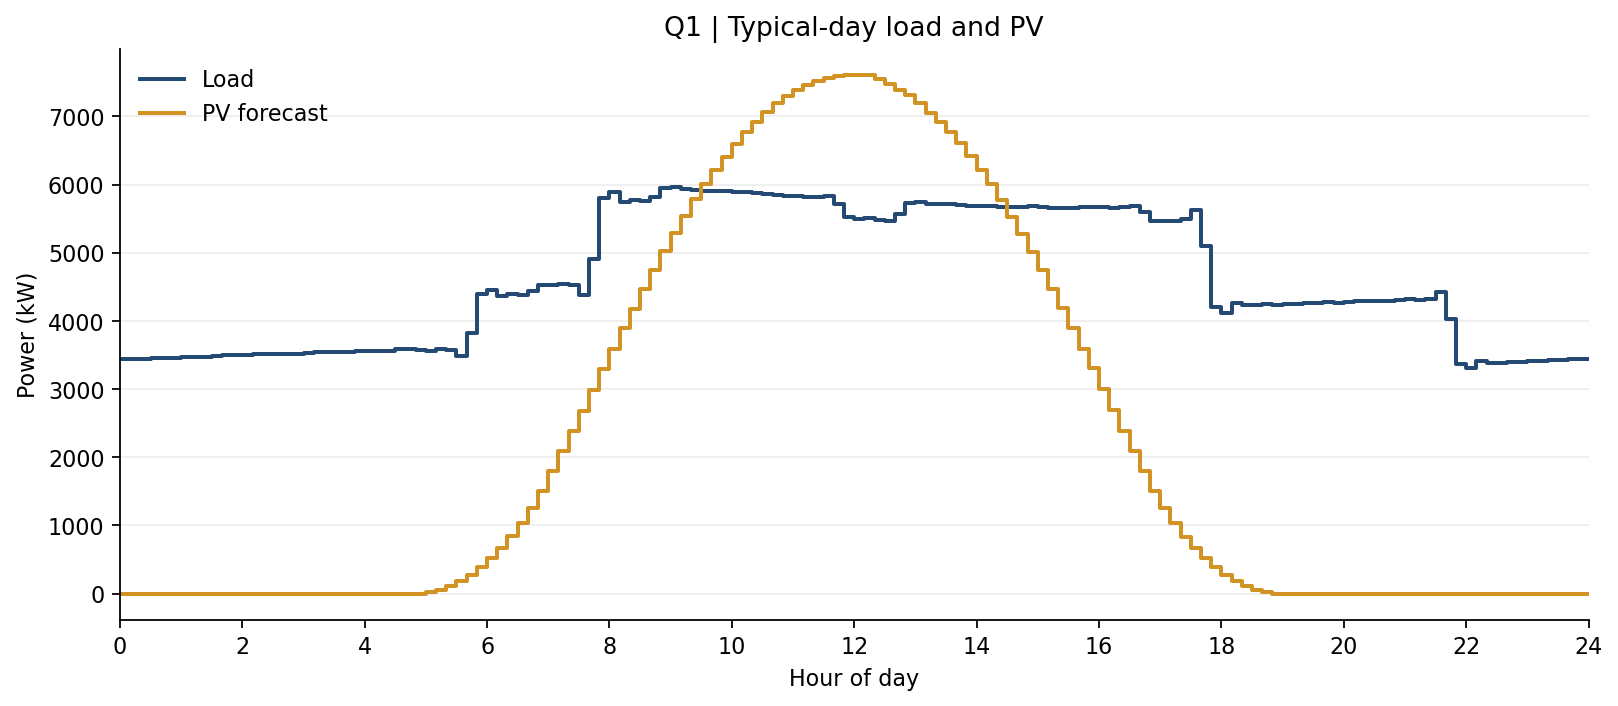

In [14]:
fig,ax = plt.subplots(figsize=(10,4.3),layout='constrained')
step(ax,load/dt_h,color='#244A73',linewidth=1.8,label='Load')
step(ax,pv/dt_h,color='#D29324',linewidth=1.8,label='PV forecast')
ax.set_title('Q1 | Typical-day load and PV')
ax.set_ylabel('Power (kW)')
ax.legend(loc='upper left',frameon=False)
finish_axis(ax)
save_and_show(fig,'01_load_pv.png')


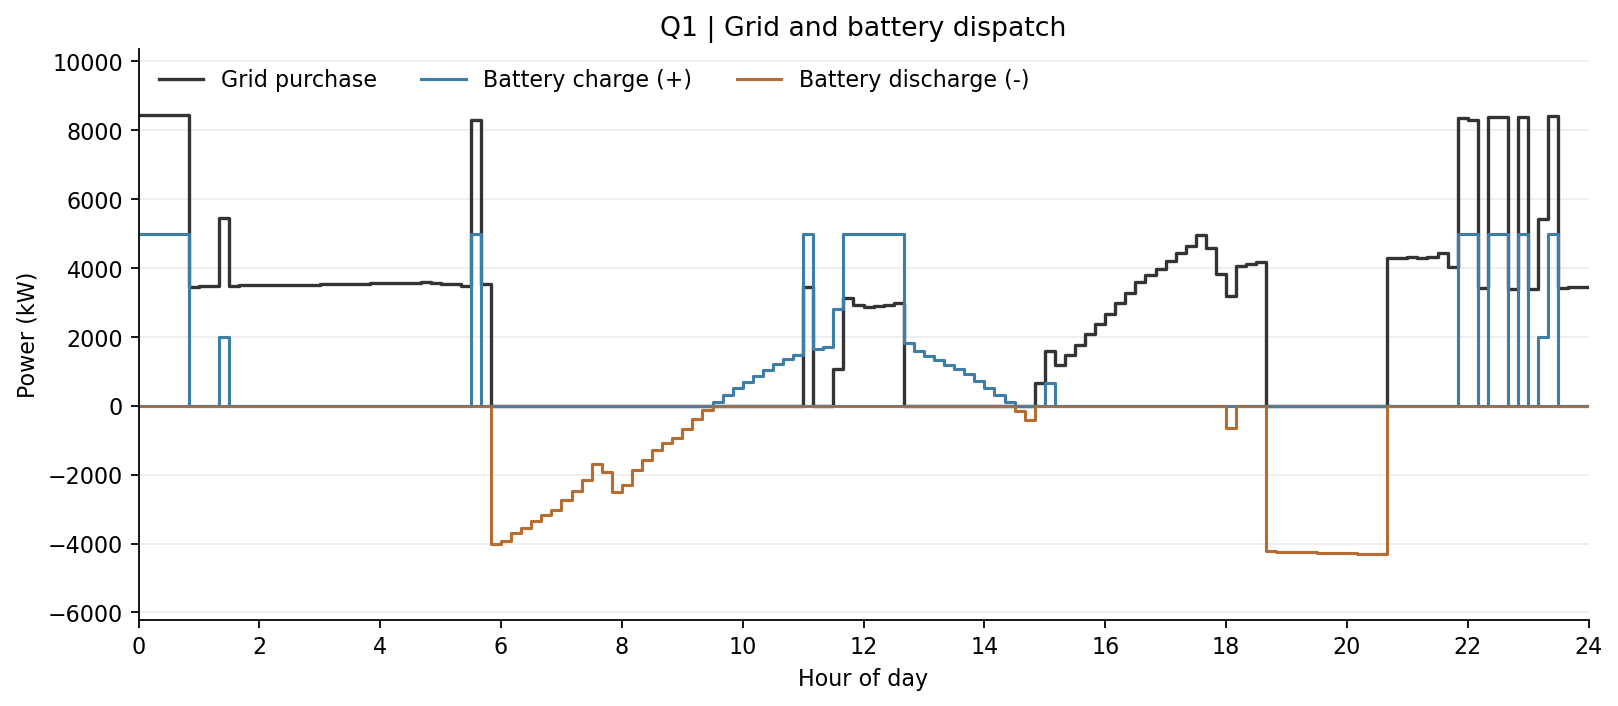

In [15]:
fig,ax = plt.subplots(figsize=(10,4.3),layout='constrained')
step(ax,g/dt_h,color='#333333',linewidth=1.5,label='Grid purchase')
step(ax,c/dt_h,color='#3D7DA6',linewidth=1.4,label='Battery charge (+)')
step(ax,-d/dt_h,color='#B56D32',linewidth=1.4,label='Battery discharge (-)')
ax.axhline(0,color='#777777',linewidth=.7)
ax.set_title('Q1 | Grid and battery dispatch')
ax.set_ylabel('Power (kW)')
ax.legend(loc='upper left',ncol=3,frameon=False)
ax.margins(y=.15)
finish_axis(ax)
save_and_show(fig,'02_dispatch.png')


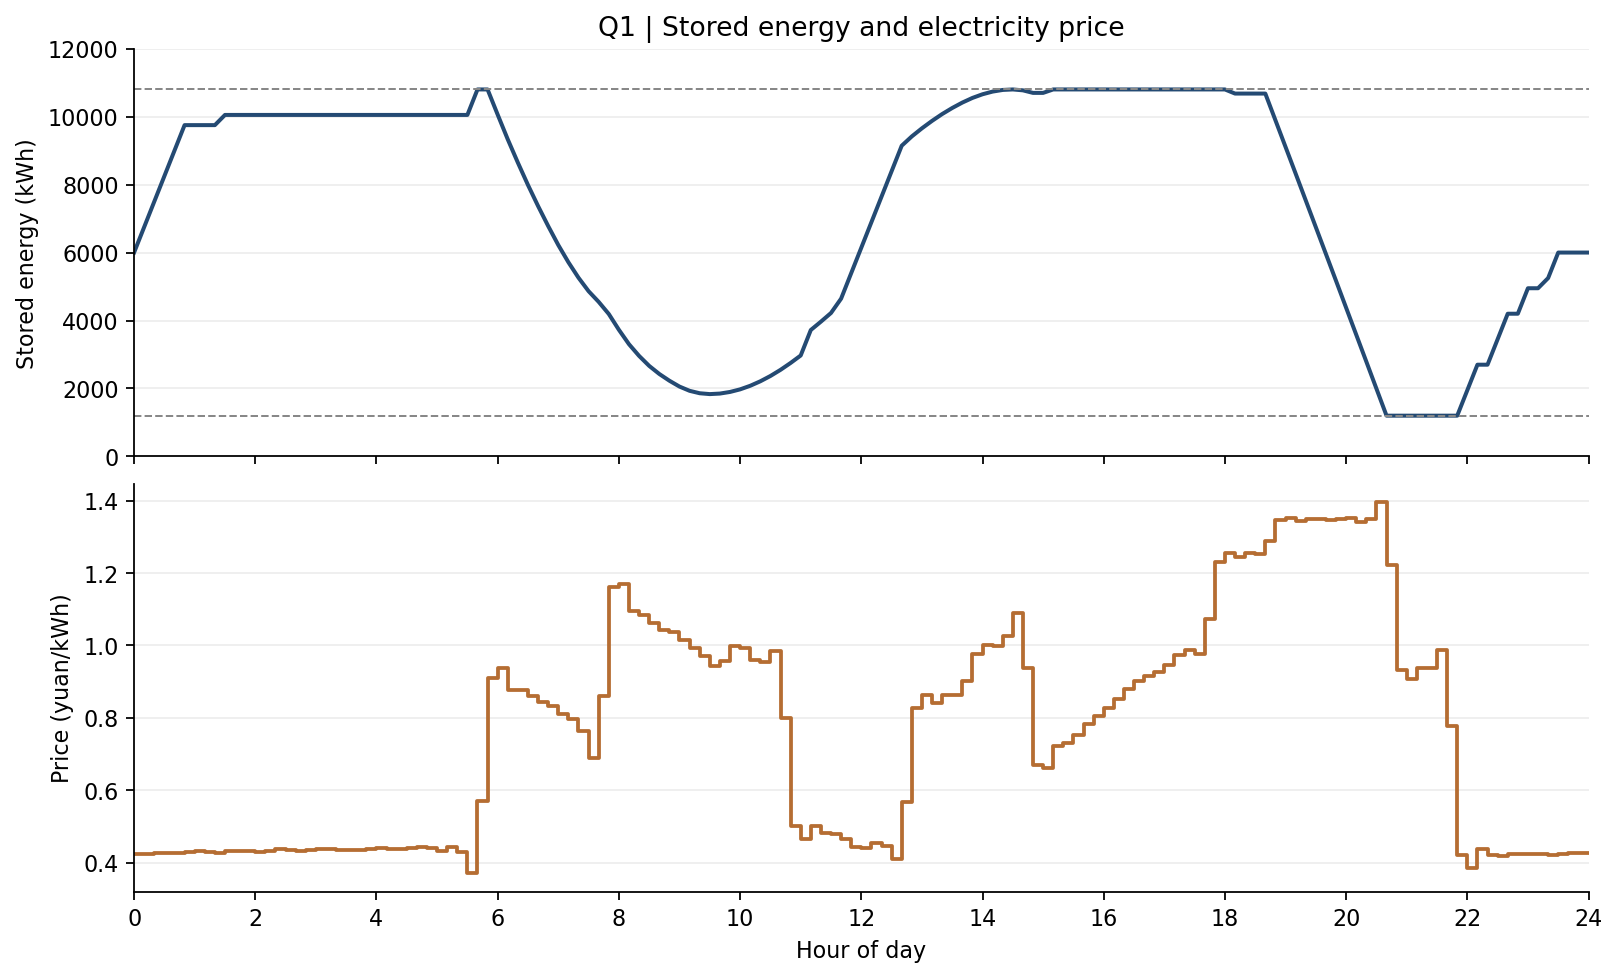

In [16]:
fig,axes = plt.subplots(2,1,figsize=(10,6),sharex=True,layout='constrained')
axes[0].plot(np.arange(n+1)*dt_h,E,color='#244A73',linewidth=1.8)
for value in [E_min,E_max]:
    axes[0].axhline(value,color='#888888',linestyle='--',linewidth=.9)
axes[0].set_ylim(0,max(12000,E_max*1.1))
axes[0].set_ylabel('Stored energy (kWh)')
axes[0].set_title('Q1 | Stored energy and electricity price')
axes[0].grid(axis='y',alpha=.22)
step(axes[1],price,color='#B56D32',linewidth=1.7)
axes[1].set_ylabel('Price (yuan/kWh)')
finish_axis(axes[1])
save_and_show(fig,'03_storage_price.png')


## 12. 导出结果
输出使用明确的00:00–24:00物理区间。CSV保存未舍入计算值；模板时间口径确认后再统一导出正式Excel。


In [17]:
schedule.to_csv(OUTPUT/'dispatch_10min.csv',index=False,encoding='utf-8-sig')
table1.to_csv(OUTPUT/'paper_table1.csv',index=False,encoding='utf-8-sig')
table2.to_csv(OUTPUT/'paper_table2.csv',index=False,encoding='utf-8-sig')
comparison.to_csv(OUTPUT/'strategy_comparison.csv',index=False,encoding='utf-8-sig')
check_table.to_csv(OUTPUT/'physical_checks.csv',index=False,encoding='utf-8-sig')
pd.DataFrame({'minute':np.arange(n+1)*10,'stored_energy_kwh':E}).to_csv(
    OUTPUT/'storage_states.csv',index=False,encoding='utf-8-sig')
summary = {
    'status':'PASS', 'cost_yuan':cost, 'grid_kwh':float(g.sum()),
    'baseline_cost_yuan':baseline_cost,'savings_percent':savings_pct,
    'method':method,'lp_lower_bound_yuan':lp_lower_bound,
    'time_mapping':'PROVISIONAL: sample as preceding 10-minute average power',
    'eta_c':eta_c,'eta_d':eta_d,'initial_kwh':E_initial,'terminal_kwh':E_terminal,
    'storage_min_kwh':E_min,'storage_max_kwh':E_max,
    'charge_power_max_kw':P_charge_max,'discharge_power_max_kw':P_discharge_max,
    'allow_curtailment':ALLOW_CURTAILMENT,'allow_grid_export':False,
    'input_numeric_sha256':hashlib.sha256(input_values.tobytes()).hexdigest(),
    'checks':{k:bool(v) for k,v in checks.items()},
}
(OUTPUT/'summary.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2),encoding='utf-8')
print('Q1 NOTEBOOK: PASS')
print(f'购电费: {cost:.4f}元 | 购电量: {g.sum():.4f}kWh')
print('输出目录:',OUTPUT.name)


Q1 NOTEBOOK: PASS
购电费: 35126.9486元 | 购电量: 59482.6990kWh
输出目录: q1_notebook_results


## 13. 现在交给队友什么

- **建模手：**确认时间、电量、效率和弃光假设；核对第4—8节的约束与最优性解释。
- **论文手：**第9节两张表、第10节策略对照、第11节三张图，以及第8节验证结果。
- **编程手：**本地从头运行全部单元格，通过检查后再开始第二问。后续仍需要把预测器、计划器、实际执行与费用结算分开。

第一问还没有使用天气预测、机器学习或未来实际数据。它提供了确定性调度基线，后面的问题在此基础上增加不确定性。
